# v3qc sanity check — matrices + panel composition

**Created 2026-05-16.** Verify the rebuilt v3qc matrices before running SEEDMIX_S1 eval.

## Checks

1. **Shape + sample composition** — 231 founders, 5772 + 9947 present as PG-substituted, correct per-chrom record counts
2. **Per-founder carrier counts in cn_var** — distribution should look reasonable; no founder suspiciously empty
3. **Cactus vs PG carrier-rate balance** — v3 had cactus founders carrying ~41% more k-mer mass than PG (the h-bias source). v3qc with QC + PG-substitution should show better balance
4. **5772/9947 swap verification** — these founders' cn_var profiles should now look like PG founders (filtered), not like the old cactus-derived columns
5. **cn_full density per chrom** — should be in the 1-15% range (v3 baseline ~10%)
6. **AC distribution in cn_var** matches what we expected from the VCF

In [1]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

V3QC_DIR = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/poolfreq/data')
V3_DIR = V3QC_DIR  # same dir, different prefix

# Load v3qc cn_var
cn_var_qc = sp.load_npz(V3QC_DIR / 'cn_var_231_v3qc.cn_var.npz')
meta_qc = np.load(V3QC_DIR / 'cn_var_231_v3qc.meta.npz', allow_pickle=True)
founders_qc = np.array([str(f) for f in meta_qc['founders']])
chrom_qc = np.array([str(c) for c in meta_qc['chrom']])
print(f'cn_var_v3qc: shape={cn_var_qc.shape}, dtype={cn_var_qc.dtype}, nnz={cn_var_qc.nnz:,}, density={cn_var_qc.nnz/(cn_var_qc.shape[0]*cn_var_qc.shape[1])*100:.3f}%')
print(f'founders: {len(founders_qc)}')
print('chrom record counts:')
for c, n in zip(*np.unique(chrom_qc, return_counts=True)):
    print(f'  {c}: {n:,}')
print(f'\nfirst 5 founders: {list(founders_qc[:5])}')
print(f'5772 in panel: {"5772" in founders_qc}')
print(f'9947 in panel: {"9947" in founders_qc}')

cn_var_v3qc: shape=(231, 4670260), dtype=int8, nnz=68,604,522, density=6.359%
founders: 231
chrom record counts:


  Chr1: 1,182,128
  Chr2: 752,851
  Chr3: 895,287
  Chr4: 769,600
  Chr5: 1,070,394

first 5 founders: ['10002', '10006', '159', '5784', '5811']
5772 in panel: True
9947 in panel: True


## Check 1 — Compare v3 vs v3qc cn_var to see what changed

In [2]:
# Load v3 baseline cn_var
cn_var_v3 = sp.load_npz(V3_DIR / 'cn_var_231_v3.cn_var.npz')
meta_v3 = np.load(V3_DIR / 'cn_var_231_v3.meta.npz', allow_pickle=True)
founders_v3 = np.array([str(f) for f in meta_v3['founders']])

print(f'cn_var_v3:   shape={cn_var_v3.shape}, nnz={cn_var_v3.nnz:,}, density={cn_var_v3.nnz/(cn_var_v3.shape[0]*cn_var_v3.shape[1])*100:.3f}%')
print(f'cn_var_v3qc: shape={cn_var_qc.shape}, nnz={cn_var_qc.nnz:,}, density={cn_var_qc.nnz/(cn_var_qc.shape[0]*cn_var_qc.shape[1])*100:.3f}%')
print(f'\nv3 founders identical to v3qc: {set(founders_v3)==set(founders_qc)}')
diff_founders = set(founders_v3) ^ set(founders_qc)
if diff_founders:
    print(f'  symmetric diff: {diff_founders}')

cn_var_v3:   shape=(231, 7693558), nnz=144,776,726, density=8.146%
cn_var_v3qc: shape=(231, 4670260), nnz=68,604,522, density=6.359%

v3 founders identical to v3qc: True


## Check 2 — Per-founder carrier counts in cn_var (cactus vs PG balance)

Cactus founders (haploid) and PG founders (was diploid, now collapsed to carrier-status haploid) should have comparable distributions. Old v3 had a notable cactus-vs-PG asymmetry; let's see if v3qc is more balanced.

In [3]:
# Cactus = 78 cactus founders (after exclusion of 5772, 9947)
# PG = 153 founders (151 original PG + 5772 + 9947 substituted)
import json
split_path = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/data/founder_split_cactus_pg.json')
if split_path.exists():
    split = json.load(open(split_path))
    cactus_v3 = set(split['cactus'])
else:
    # Fall back: parse from the cactus VCF sample list
    cactus_v3 = set(open('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/pangenie_genotyping/data/cactus_80_ecotypes.txt').read().split())
# For v3qc, drop the 2 swapped from cactus set
cactus_qc = cactus_v3 - {'5772', '9947'}
pg_qc = set(founders_qc) - cactus_qc
print(f'v3qc cactus founders: {len(cactus_qc)} (expected 78)')
print(f'v3qc PG founders: {len(pg_qc)} (expected 153)')
assert len(cactus_qc) == 78, f'cactus count mismatch: {len(cactus_qc)}'
assert len(pg_qc) == 153, f'PG count mismatch: {len(pg_qc)}'

v3qc cactus founders: 78 (expected 78)
v3qc PG founders: 153 (expected 153)


In [4]:
# Per-founder carrier count = row sum in cn_var
carrier_counts_qc = np.array(cn_var_qc.sum(axis=1)).flatten()
carrier_counts_v3 = np.array(cn_var_v3.sum(axis=1)).flatten()

df_qc = pd.DataFrame({'founder': founders_qc, 'carriers_v3qc': carrier_counts_qc})
df_v3 = pd.DataFrame({'founder': founders_v3, 'carriers_v3': carrier_counts_v3})
df = df_qc.merge(df_v3, on='founder', how='outer')
df['side'] = df['founder'].map(lambda f: 'cactus' if f in cactus_qc else 'pg')
# Mark the swap targets
df['swapped'] = df['founder'].isin({'5772', '9947'})
df.head()

,founder,carriers_v3qc,carriers_v3,side,swapped
0,100001,217289,769808,pg,False
1,100002,217023,773757,pg,False
2,10002,467302,550617,cactus,False
3,10006,560920,656600,cactus,False
4,10011,186405,661425,pg,False


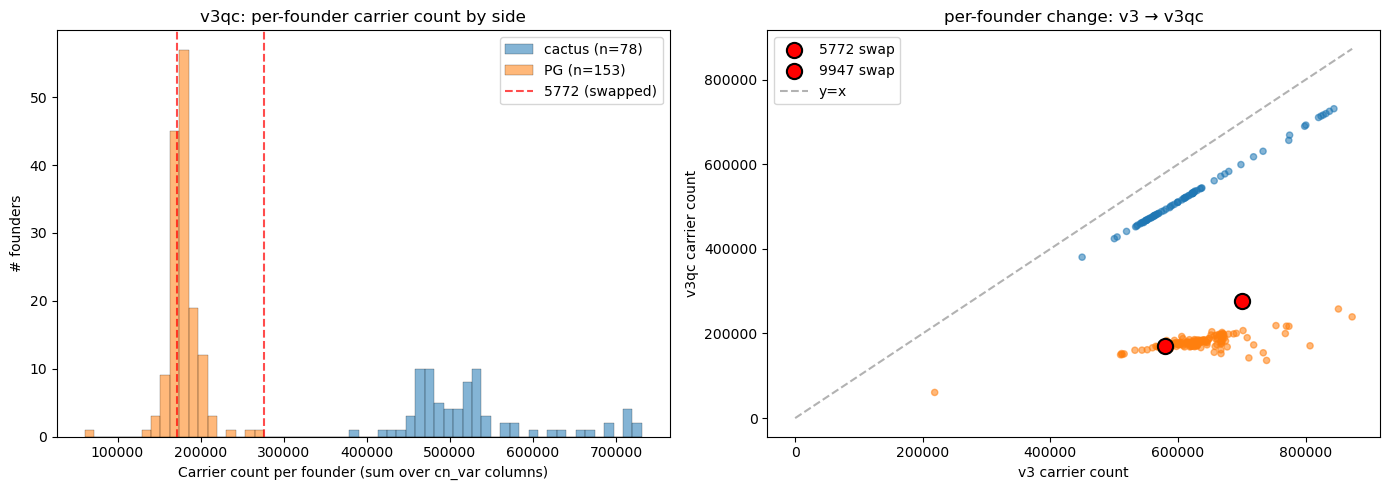


Carrier count summary by side (v3qc):
        count      mean      std       min       25%       50%       75%  \
side                                                                       
cactus   78.0  528059.0  79856.0  380345.0  473705.0  510285.0  540652.0   
pg      153.0  179189.0  19878.0   60699.0  170897.0  177745.0  185354.0   

             max  
side              
cactus  731142.0  
pg      275916.0  

Cactus/PG mean ratio (h-bias proxy):
  v3:   cactus/PG = 0.981
  v3qc: cactus/PG = 2.947
  (closer to 1.0 = more balanced; v3 was supposedly ~1.41 from the +41% h-bias)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by side (v3qc)
ax = axes[0]
bins = np.linspace(df['carriers_v3qc'].min(), df['carriers_v3qc'].max(), 60)
ax.hist(df.loc[df.side=='cactus', 'carriers_v3qc'], bins=bins, alpha=0.55, label=f'cactus (n=78)', color='#1f77b4', edgecolor='black', lw=0.3)
ax.hist(df.loc[df.side=='pg', 'carriers_v3qc'], bins=bins, alpha=0.55, label=f'PG (n=153)', color='#ff7f0e', edgecolor='black', lw=0.3)
# Mark swapped
for _, r in df[df.swapped].iterrows():
    ax.axvline(r['carriers_v3qc'], color='red', linestyle='--', alpha=0.7, label=f"{r['founder']} (swapped)" if r['founder']=='5772' else None)
ax.set_xlabel('Carrier count per founder (sum over cn_var columns)')
ax.set_ylabel('# founders')
ax.set_title('v3qc: per-founder carrier count by side')
ax.legend()

# Old vs new comparison
ax = axes[1]
colors = df['side'].map({'cactus': '#1f77b4', 'pg': '#ff7f0e'}).fillna('gray')
ax.scatter(df['carriers_v3'], df['carriers_v3qc'], c=colors, alpha=0.55, s=20)
for _, r in df[df.swapped].iterrows():
    ax.scatter(r['carriers_v3'], r['carriers_v3qc'], c='red', s=120, edgecolor='black', lw=1.5, label=f"{r['founder']} swap", zorder=10)
ax.plot([0, df[['carriers_v3','carriers_v3qc']].max().max()], [0, df[['carriers_v3','carriers_v3qc']].max().max()], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel('v3 carrier count')
ax.set_ylabel('v3qc carrier count')
ax.set_title('per-founder change: v3 → v3qc')
ax.legend()

plt.tight_layout()
plt.savefig('plots/V3QC_CARRIER_COUNTS.png', dpi=140, bbox_inches='tight')
plt.show()

# Summary stats by side
print('\nCarrier count summary by side (v3qc):')
print(df.groupby('side')['carriers_v3qc'].describe().round(0))
print('\nCactus/PG mean ratio (h-bias proxy):')
cact_mean = df.loc[df.side=='cactus', 'carriers_v3qc'].mean()
pg_mean = df.loc[df.side=='pg', 'carriers_v3qc'].mean()
cact_mean_v3 = df.loc[df.side=='cactus', 'carriers_v3'].mean()
pg_mean_v3 = df.loc[df.side=='pg', 'carriers_v3'].mean()
print(f'  v3:   cactus/PG = {cact_mean_v3/pg_mean_v3:.3f}')
print(f'  v3qc: cactus/PG = {cact_mean/pg_mean:.3f}')
print(f'  (closer to 1.0 = more balanced; v3 was supposedly ~1.41 from the +41% h-bias)')

## Check 3 — Swap verification: 5772 and 9947 cn_var profiles

These were on the cactus side in v3 (with 5772 being mislabeled to T980). In v3qc, they're PG-genotyped from clean short reads + filtered by GQ+V4. Their carrier-count and overlap pattern should now look like a typical PG founder, not like the old cactus mislabel.

In [6]:
# 5772 vs T980 (6150) comparison: in v3, 5772 was mislabeled as T980's genome
# (cactus k-mer J=0.964). In v3qc, 5772 is real Set-1 from PG.
# Their cn_var Jaccard should be MUCH lower in v3qc than in v3.
def jaccard(c1, c2):
    inter = (c1.multiply(c2)).nnz
    union = c1.nnz + c2.nnz - inter
    return inter / union if union > 0 else 0.0

def row(cn, founders, fid):
    idx = np.where(founders == fid)[0][0]
    return cn.getrow(idx)

# We need to compare on the SAME variant set. v3 and v3qc have different
# variant sets (different filters). So this is approximate — compute carrier
# counts on each version separately.
print('5772 (Set-1) vs 6150 (T980) — cn_var Jaccard:')
for cn, founders, label in [(cn_var_v3, founders_v3, 'v3'), (cn_var_qc, founders_qc, 'v3qc')]:
    r5772 = row(cn, founders, '5772')
    r6150 = row(cn, founders, '6150')
    j = jaccard(r5772, r6150)
    print(f'  {label}: J = {j:.4f}  (5772 nnz={r5772.nnz}, 6150 nnz={r6150.nnz})')
print('\nExpected: v3 J was high (mislabel made 5772 look like T980). v3qc J should drop (real Set-1).')

5772 (Set-1) vs 6150 (T980) — cn_var Jaccard:
  v3: J = 0.8828  (5772 nnz=579999, 6150 nnz=568997)
  v3qc: J = 0.1810  (5772 nnz=171016, 6150 nnz=483621)

Expected: v3 J was high (mislabel made 5772 look like T980). v3qc J should drop (real Set-1).


In [7]:
# Per-side pairwise mean Jaccard (within cactus, within PG, between)
# Sample to keep runtime reasonable
rng = np.random.default_rng(42)
def pair_jaccards(cn, founders, group_a, group_b, n=50):
    a_ids = list(set(founders) & group_a)
    b_ids = list(set(founders) & group_b)
    sampled = []
    for _ in range(n):
        f1 = rng.choice(a_ids)
        f2 = rng.choice(b_ids)
        if f1 == f2: continue
        sampled.append(jaccard(row(cn, founders, f1), row(cn, founders, f2)))
    return np.array(sampled)

print('Per-side pairwise mean Jaccard (n=50 random pairs each):')
for cn, founders, label in [(cn_var_v3, founders_v3, 'v3'), (cn_var_qc, founders_qc, 'v3qc')]:
    j_cc = pair_jaccards(cn, founders, cactus_qc, cactus_qc).mean()
    j_pp = pair_jaccards(cn, founders, pg_qc, pg_qc).mean()
    j_cp = pair_jaccards(cn, founders, cactus_qc, pg_qc).mean()
    print(f'  {label}:  cactus-cactus={j_cc:.3f}   PG-PG={j_pp:.3f}   cactus-PG={j_cp:.3f}')

Per-side pairwise mean Jaccard (n=50 random pairs each):


  v3:  cactus-cactus=0.281   PG-PG=0.326   cactus-PG=0.273


  v3qc:  cactus-cactus=0.288   PG-PG=0.438   cactus-PG=0.171


## Check 4 — cn_full density per chrom (sanity)

In [8]:
cn_full_dir = V3QC_DIR / 'cn_full_231_v3qc'
print('cn_full per-chrom density:')
for chrom in ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5']:
    p = cn_full_dir / f'cn_{chrom}.cn.npz'
    if p.exists():
        M = sp.load_npz(p)
        dens = M.nnz / (M.shape[0] * M.shape[1]) * 100
        print(f'  {chrom}: shape={M.shape}  nnz={M.nnz:,}  density={dens:.3f}%')
    else:
        print(f'  {chrom}: not yet built (in progress)')

cn_full per-chrom density:
  Chr1: not yet built (in progress)


  Chr2: shape=(231, 13945182)  nnz=336,644,849  density=10.450%


  Chr3: shape=(231, 17200284)  nnz=417,896,750  density=10.518%


  Chr4: shape=(231, 13296992)  nnz=299,025,873  density=9.735%


  Chr5: shape=(231, 20423491)  nnz=482,915,303  density=10.236%


## Check 5 — Per-founder k-mer count balance (for completed cn_full chroms)

This is the diagnostic for the +41% cactus h-bias. v3 had cactus founders carrying ~more k-mers than PG founders → EM over-credited cactus. v3qc should be more balanced because (a) the 2 worst-quality cactus assemblies (5772, 9947) are now PG-genotyped, and (b) PG-side excess-het records were dropped by V4 filter.

In [9]:
# Load completed cn_full chroms and compute per-founder k-mer count (row sum)
kmer_counts = {}
for chrom in ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5']:
    p = cn_full_dir / f'cn_{chrom}.cn.npz'
    if p.exists():
        M = sp.load_npz(p)
        kmer_counts[chrom] = np.array(M.sum(axis=1)).flatten()

for chrom, counts in kmer_counts.items():
    cact_mask = np.array([f in cactus_qc for f in founders_qc])
    cact_mean = counts[cact_mask].mean()
    pg_mean = counts[~cact_mask].mean()
    ratio = cact_mean / pg_mean
    print(f'{chrom}: cactus mean K_f = {cact_mean:,.0f}   PG mean K_f = {pg_mean:,.0f}   ratio = {ratio:.3f}')
print('\nv3 ratio was reportedly ~1.005 (K_f near-equal) but per-founder PRIVATE k-mers differed ~2x — see project_kmer_imbalance_investigation memory')

Chr2: cactus mean K_f = 1,516,162   PG mean K_f = 1,427,348   ratio = 1.062
Chr3: cactus mean K_f = 1,885,535   PG mean K_f = 1,770,098   ratio = 1.065
Chr4: cactus mean K_f = 1,343,684   PG mean K_f = 1,269,402   ratio = 1.059
Chr5: cactus mean K_f = 2,169,831   PG mean K_f = 2,050,121   ratio = 1.058

v3 ratio was reportedly ~1.005 (K_f near-equal) but per-founder PRIVATE k-mers differed ~2x — see project_kmer_imbalance_investigation memory


## Outputs

- `V3QC_CARRIER_COUNTS.png` — per-founder carrier count distribution + v3-vs-v3qc scatter